In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
dataset  = pd.read_csv(r"C:\Users\Manish Chahar\Documents\datasets\heart.xls")
dataset.head(4)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1


In [3]:
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
x =dataset.iloc[:,:-1]
y = dataset["target"]

In [5]:
lr = LogisticRegression(C=100, max_iter=2000,multi_class="ovr")

In [6]:
from mlxtend.feature_selection import SequentialFeatureSelector

In [7]:
sfs  = SequentialFeatureSelector(lr,k_features=10,forward=True)
sfs.fit(x,y)

c:\Users\Manish Chahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\Manish Chahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\Manish Chahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\Manish Chahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params

SequentialFeatureSelector(estimator=LogisticRegression(C=100, max_iter=2000,
                                                       multi_class='ovr'),
                          k_features=(10, 10), scoring='accuracy')

In [8]:
sfs.feature_names

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [9]:
sfs.k_feature_names_

('sex',
 'cp',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal')

In [10]:
x_final= x[list(sfs.k_feature_names_)]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x_final,y,test_size=0.2,random_state=55)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [13]:
lr.fit(x_train_scaled,y_train)

LogisticRegression(C=100, max_iter=2000, multi_class='ovr')

In [14]:
lr.score(x_test_scaled,y_test)*100

88.52459016393442

In [15]:
y_pred = lr.predict(x_test_scaled)

In [16]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85        25
           1       0.87      0.94      0.91        36

    accuracy                           0.89        61
   macro avg       0.89      0.87      0.88        61
weighted avg       0.89      0.89      0.88        61



In [18]:
accuracy_score(y_test,y_pred)*100

88.52459016393442

In [19]:
cm = confusion_matrix(y_test,y_pred)

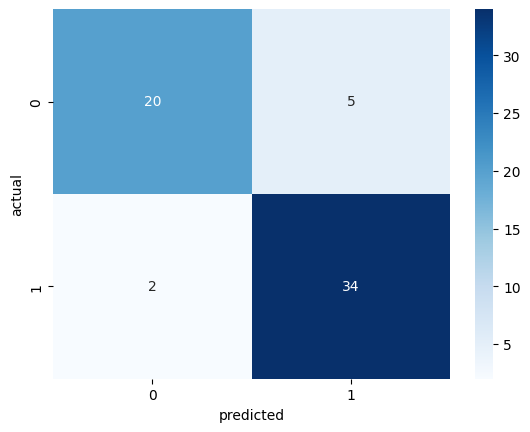

In [20]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()